# EXERCISES: LECTURE 3

# 1-Nasty Integral

Using Monte Carlo integration, check that

$$ \int_0^\infty x^3 \exp\left(-\frac{x^2}{2\sigma^2}\right) \,dx = 2\sigma^4 .$$

- Does the result converge with the number of samples? And how does the error go down?
- Do it many times. For a given $N$, how are the result distributed? We'll talk about model fitting at lenght later on, but for now try to fit it by hand with a parametrized model. (If N is large enough you should get something that looks *very* accurate! And if $N$ is small?)
- How does the distribution change if $N$ increases?

(Hint: think about sample mean and sample variance)

In [2]:
import numpy as np
import scipy.stats
import pylab as plt

### Simple fast comparison:

In [181]:

N = 10000
sigma = 1
x_i = np.random.normal(loc=0,scale= sigma, size=N)

x_i = np.abs(x_i)

# mask = x_i > 0   # Masking values will not be accurate. The values at 0 might blur the values as we are taking boundaries
# x_i = x_i[mask]

def fun(x,s):
    return s*((np.pi/2)**0.5)*(x**3)

solution_check = 2*(sigma**4)

my_solution = np.mean(fun(x_i,sigma))

print(my_solution,solution_check)
# plt.hist(x_i)
# plt.show()



2.0085071416884595 2


### The convergence of the solution regarding N values

In [185]:
solution_list = []
N_list = []
sigma_s = []
sigma = 1
error_list = []
def fun(x,s):
    return s*((np.pi/2)**0.5)*(x**3)

solution_check = 2*(sigma**4)

for n in range(int(10),int(30000), int(100)):
   
 x_i = np.random.normal(loc=0,scale= sigma, size=n)
 x_i = np.abs(x_i)
 
 mean = np.mean(fun(x_i,sigma))
 std = np.std(fun(x_i,sigma))
 error = std/np.sqrt(n)
 
 error_list.append(error)
 solution_list.append(mean)
 N_list.append(n)



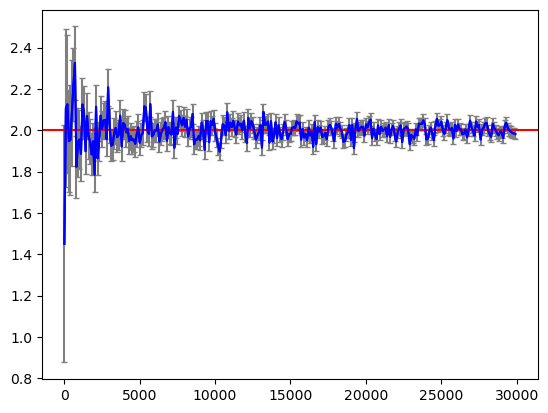

In [186]:
fig , ax = plt.subplots()
ax.errorbar(N_list, solution_list, yerr=error_list,
            fmt='b', ecolor='gray', capsize=2)
ax.plot(N_list,solution_list, color = 'blue')
ax.axhline(solution_check, color= 'red')
plt.show()

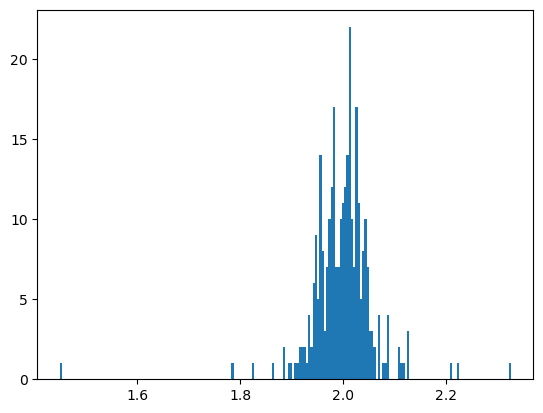

In [187]:
# Solutions are parametrized to Guassian:

plt.hist(solution_list, bins= 200)
plt.show()

# Results:
* Increasing the number of samples:

      1- inreases the accuracy of the final result

      2- the distribution (histogram) becomes more Gaussian and sharp at the correct value.
* The error goes down as we increase the number of samples.

# 2. Kicking horses

A famous early  application of low-number statistics was an analysis of Prussian cavalryman horse-kick deaths by [Bortkiewicz](https://www.wikiwand.com/en/Ladislaus_Bortkiewicz) in 1898.

He studied the distribution of 122 men kicked to death by horses among 10 Prussian army corps within 20 years (so a total number of corpes of 200). He recorded the number of corps with a given number of deaths:

| Number of deaths | Number of groups |
| --- | --- |
| 0 | 109 |
| 1 | 65 |
| 2 | 22 |
| 3 | 3 |
| 4 | 1 |

- Plot the resulting probability distribution. Careful with the normalization
- How does it look like? Again try to fit it by hand.

In [210]:
n_groups = [109,65,22,3,1]
n_deaths = [0,1,2,3,4]
total = np.sum(n_groups)
freq = n_groups/total

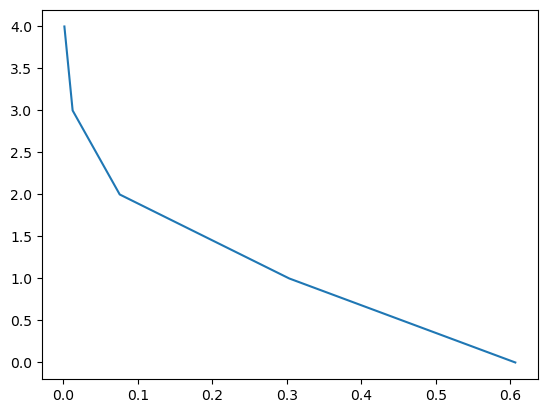

In [ ]:
dist = scipy.stats.poisson(0.5).pmf(n_deaths) # mu = 0.5 and the pmf holds the values of k (The event = n_deaths)
plt.plot(dist,n_deaths)
plt.show()

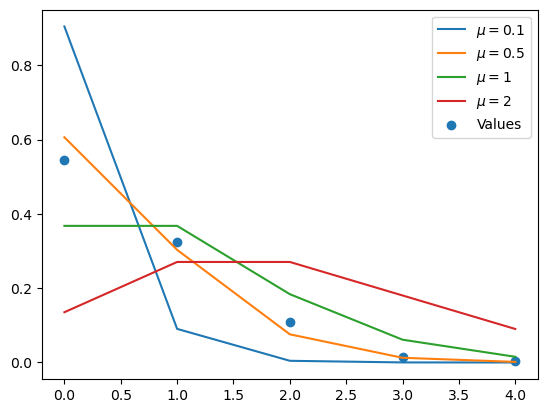

In [ ]:
for mu in [0.1,0.5,1,2]:
    p = scipy.stats.poisson(mu).pmf(n_deaths)
    plt.plot(n_deaths, p,label='$\mu='+str(mu)+"$")

plt.scatter(n_deaths,freq, label='Values')
plt.legend()
plt.show()